<a href="https://colab.research.google.com/github/Rudragehlot/Digital-Ad-Performance-Analysis-Facebook-AdWord-Conversions/blob/main/Marketing_Campaign_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing python libs

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint
import warnings
warnings.filterwarnings('ignore')

importing dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubhamdamai/ab-testing-analysis-facebook-vs-adword")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ab-testing-analysis-facebook-vs-adword' dataset.
Path to dataset files: /kaggle/input/ab-testing-analysis-facebook-vs-adword


In [ ]:
import os

# List the contents of the downloaded directory to find the correct CSV file name
print(os.listdir(path))

['A_B_testing_dataset.csv']


read the given dataset

In [ ]:
import os

# Construct the full path to the CSV file using the correct name
file_path = os.path.join(path, "A_B_testing_dataset.csv")

# loading data
df = pd.read_csv(file_path)
display(df.head())

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57


In [ ]:
df.shape

(1000, 17)

In [ ]:
df.dtypes

,0
date_of_campaign,object
facebook_ad_campaign,object
facebook_ad_views,int64
facebook_ad_clicks,int64
facebook_ad_conversions,int64
facebook_cost_per_ad,int64
facebook_ctr,float64
facebook_conversion_rate,float64
facebook_cost_per_click,float64
adword_ad_campaign,object


now, disctibing the data

In [ ]:
df['date_of_campaign']=pd.to_datetime(df['date_of_campaign'])
df.describe()

,date_of_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2023-07-04 07:13:26.399999744,2152.031000,44.196000,11.975000,156.610000,2.28316,32.696080,4.310500,4771.438000,60.128000,5.933000,124.741000,1.280950,10.807510,2.265540
min,2021-12-22 00:00:00,1050.000000,15.000000,5.000000,60.000000,0.49000,6.850000,0.960000,3715.000000,31.000000,3.000000,50.000000,0.540000,3.370000,0.580000
25%,2022-10-07 18:00:00,1600.250000,30.000000,8.000000,110.000000,1.36750,18.052500,2.337500,4258.250000,45.000000,4.000000,86.000000,0.940000,6.970000,1.470000
50%,2023-07-20 12:00:00,2123.500000,44.500000,12.000000,156.000000,2.07000,27.120000,3.600000,4808.500000,60.000000,6.000000,124.000000,1.260000,9.720000,2.030000
75%,2024-03-24 00:00:00,2706.250000,58.000000,16.000000,205.000000,2.92250,41.880000,5.610000,5300.750000,75.000000,8.000000,163.000000,1.570000,13.485000,2.802500
max,2024-12-20 00:00:00,3320.000000,73.000000,19.000000,250.000000,6.86000,118.750000,16.530000,5754.000000,89.000000,9.000000,200.000000,2.370000,29.030000,6.190000
std,NaN,661.982166,16.833328,4.298471,54.918904,1.20670,20.570796,2.751582,598.647684,17.047822,2.011606,43.809053,0.402492,5.205133,1.101846


Data Analyzing start, and we a making plots for analyzing the Facebook add Click, Conversion and Adword add click, conversion.

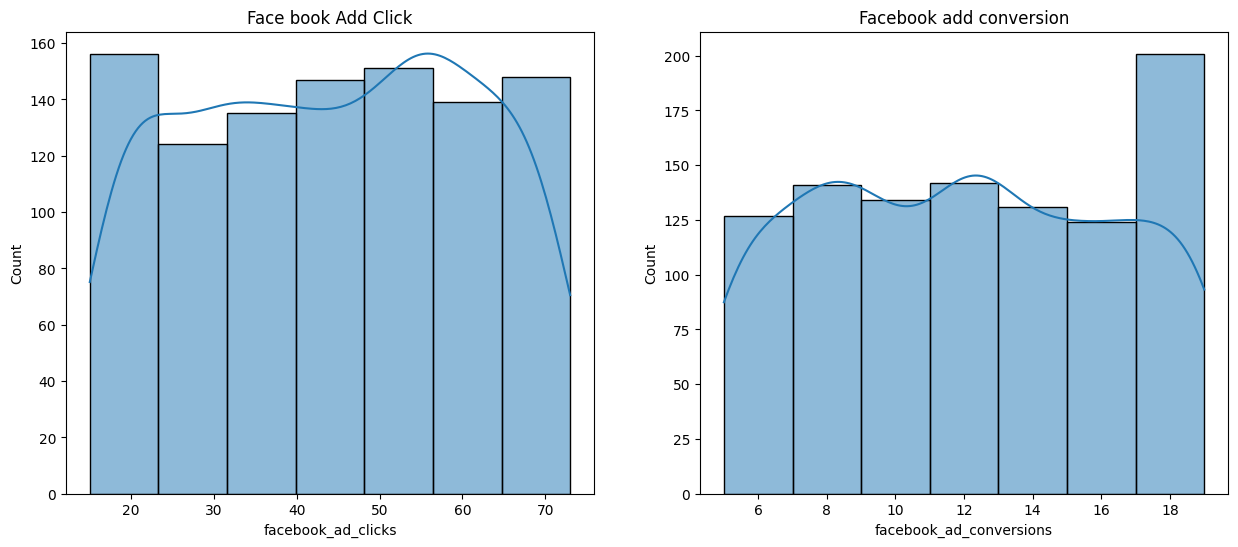

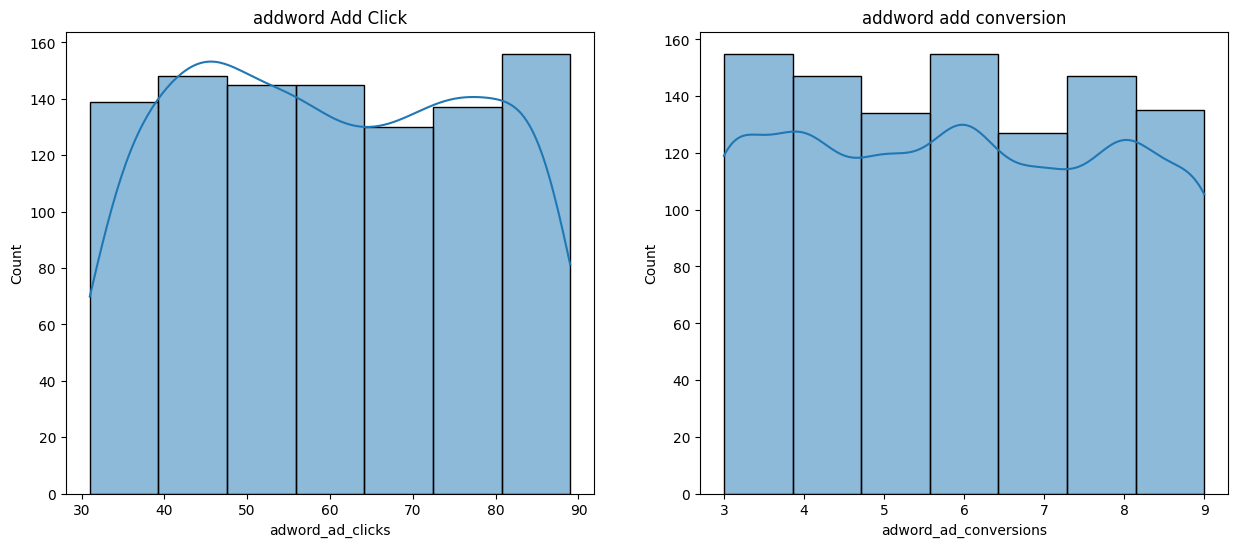

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('Face book Add Click')
sns.histplot(df['facebook_ad_clicks'], bins=7, edgecolor='k', kde=True)
plt.subplot(1,2,2)
plt.title('Facebook add conversion')
sns.histplot(df['facebook_ad_conversions'], bins=7, edgecolor='k', kde=True)
plt.show()

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('addword Add Click')
sns.histplot(df['adword_ad_clicks'], bins=7, edgecolor='k', kde=True)
plt.subplot(1,2,2)
plt.title('addword add conversion')
sns.histplot(df['adword_ad_conversions'], bins=7, edgecolor='k', kde=True)
plt.show()

now we can make a category to simplifying data

In [ ]:
def creat_convertion_cetogory(conversion_col):
  ceregory=[]
  for conversion in df[conversion_col]:
    if conversion <6:
      ceregory.append('less then 6')
    elif conversion <11:
      ceregory.append('6-10')
    elif conversion <16:
      ceregory.append('10-15')
    else :
      ceregory.append('more then 15')
  return ceregory
df['facebook conversion category']=creat_convertion_cetogory('facebook_ad_conversions')
df['adword conversion category']=creat_convertion_cetogory('adword_ad_conversions')


In [ ]:
df[['facebook_ad_conversions','facebook conversion category','adword_ad_conversions','adword conversion category']].head()

,facebook_ad_conversions,facebook conversion category,adword_ad_conversions,adword conversion category
0,14,10-15,9,6-10
1,9,6-10,6,6-10
2,15,10-15,9,6-10
3,9,6-10,3,less then 6
4,12,10-15,4,less then 6


In [ ]:
df['facebook conversion category'].value_counts()

,count
facebook conversion category,
10-15,341
6-10,337
more then 15,257
less then 6,65


In [ ]:
facebook=pd.DataFrame(df['facebook conversion category'].value_counts()).reset_index().rename(columns={'facebook conversion category':'Category'})
facebook

,Category,count
0,10-15,341
1,6-10,337
2,more then 15,257
3,less then 6,65


In [ ]:
df['adword_ad_conversions'].value_counts()

,count
adword_ad_conversions,
6,155
3,155
4,147
8,147
9,135
5,134
7,127


In [ ]:
adword=pd.DataFrame(df['adword conversion category'].value_counts()).reset_index().rename(columns={'adword conversion category':'Category'})
adword

,Category,count
0,6-10,564
1,less then 6,436


In [ ]:
category_df=pd.merge(facebook,adword,on='Category',how='outer').fillna(0)
category_df

,Category,count_x,count_y
0,10-15,341,0.0
1,6-10,337,564.0
2,less then 6,65,436.0
3,more then 15,257,0.0


In [ ]:
category_df=category_df.iloc[[2,1,0,3]]
category_df

,Category,count_x,count_y
2,less then 6,65,436.0
1,6-10,337,564.0
0,10-15,341,0.0
3,more then 15,257,0.0


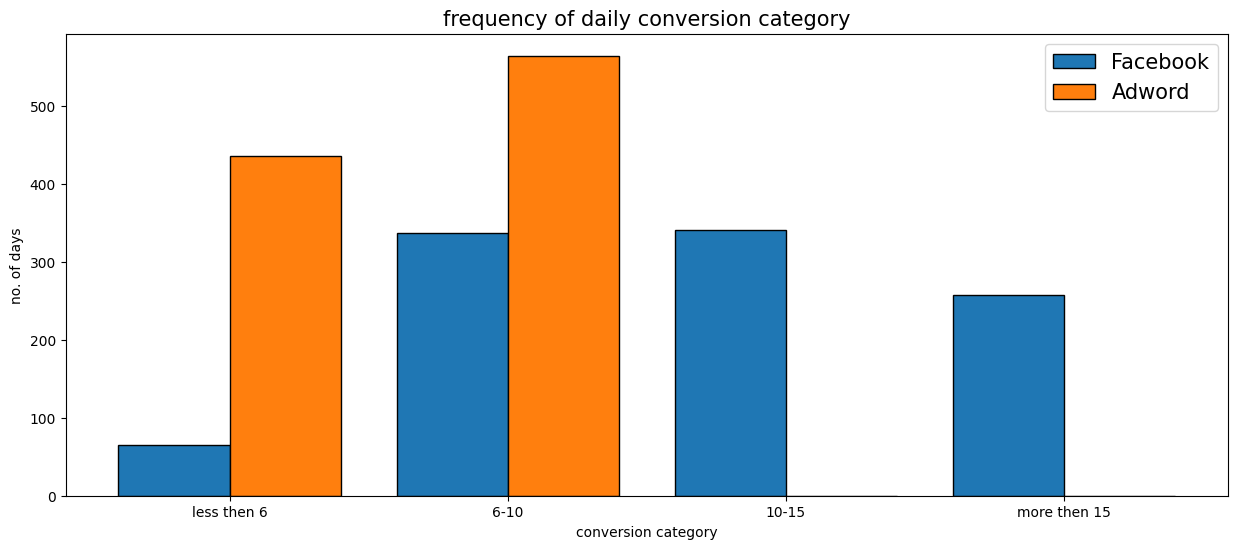

In [ ]:
from ipywidgets import Label
x_axis=np.arange(len(category_df))
plt.figure(figsize=(15,6))
plt.bar(x_axis - 0.2, category_df['count_x'],0.4, label='Facebook', linewidth=1, edgecolor='k')
plt.bar(x_axis + 0.2, category_df['count_y'],0.4, label='Adword', linewidth=1, edgecolor='k')

plt.xticks(x_axis, category_df['Category'])
plt.xlabel('conversion category')
plt.ylabel('no. of days')
plt.title('frequency of daily conversion category', fontsize=15)
plt.legend(fontsize=15)
plt.show()

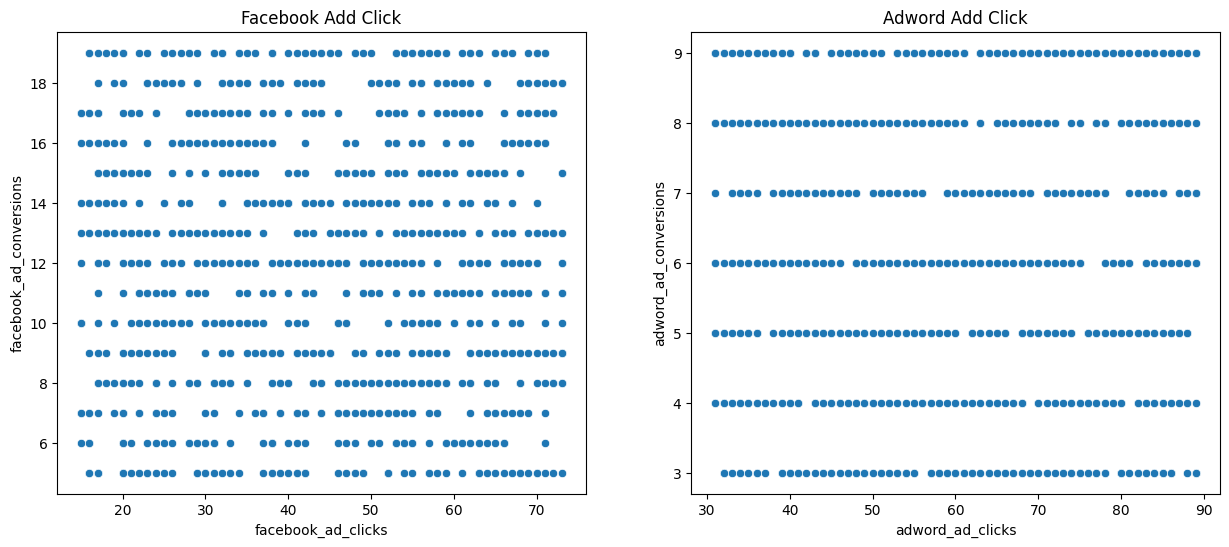

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('Facebook Add Click')
sns.scatterplot(x='facebook_ad_clicks',y='facebook_ad_conversions',data=df)
plt.xlabel('facebook_ad_clicks')
plt.ylabel('facebook_ad_conversions')
plt.subplot(1,2,2)
plt.title('Adword Add Click')
sns.scatterplot(x='adword_ad_clicks',y='adword_ad_conversions',data=df)
plt.xlabel('adword_ad_clicks')
plt.ylabel('adword_ad_conversions')
plt.show()

In [ ]:
facebook_corr= df[['facebook_ad_clicks','facebook_ad_conversions']].corr()
facebook_corr

,facebook_ad_clicks,facebook_ad_conversions
facebook_ad_clicks,1.000000,-0.005009
facebook_ad_conversions,-0.005009,1.000000


In [ ]:
addword_corr= df[['adword_ad_clicks','adword_ad_conversions']].corr()
addword_corr

,adword_ad_clicks,adword_ad_conversions
adword_ad_clicks,1.000000,0.004162
adword_ad_conversions,0.004162,1.000000


corr showing the co reletion cofisiant

In [ ]:
print('correletion coeff/n...................')
print('facebook_corr', round(facebook_corr.values[0,1],2))
print('addword_corr', round(addword_corr.values[0,1],2))

correletion coeff/n...................
facebook_corr -0.01
addword_corr 0.0


In [ ]:
df['facebook_ad_conversions'].mean()

np.float64(11.975)

In [ ]:
import scipy.stats as st

print('Mean conversion\n.............')
print('facebook:',round(df['facebook_conversion_rate'].mean(),2))
print('adword:',round(df['adword_conversion_rate'].mean(),2))

t_stats, p_value=st.ttest_ind(df['facebook_conversion_rate'],df['adword_conversion_rate'], equal_var=False)
print('t_stats:',t_stats)
print('p_value:',p_value)

if p_value<0.05:
  print('Reject the null hypothesis')
else:
  print('Fail to reject the null hypothesis')

Mean conversion
.............
facebook: 32.7
adword: 10.81
t_stats: 32.62045547744514
p_value: 7.116026506592085e-165
Reject the null hypothesis


there are facebook is work better

# now, what will happen when i go to facebook add

In [ ]:
# Code for the initial XGBoost model (now cleared as per user request)
# Please refer to the extensively tuned model for the best performance.

XGBoost Regressor for Facebook Ads:
R2 score (Accuracy): -38.49%
Mean Squared Error: 25.57


In [ ]:
# Code for the first hyperparameter tuning of XGBoost (now cleared as per user request)
# Please refer to the extensively tuned model for the best performance.

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best R2 Score from GridSearchCV: -0.00

Tunned XGBoost Regressor for Facebook Ads:
R2 score (Accuracy): -3.61%
Mean Squared Error: 19.13


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Define new features (X) including CTR, Conversion Rate, and Cost Per Click
X_fb_enhanced = df[['facebook_ad_views', 'facebook_ad_clicks', 'facebook_cost_per_ad',
                      'facebook_ctr', 'facebook_conversion_rate', 'facebook_cost_per_click']]
y_fb = df['facebook_ad_conversions']

# Split data into training and testing sets
X_train_fb_enhanced, X_test_fb_enhanced, y_train_fb, y_test_fb = train_test_split(X_fb_enhanced, y_fb, test_size=0.2, random_state=42)

# Initialize and train the XGBoost Regressor model with the best parameters found earlier
xgb_tuned_model_fb_enhanced = xgb.XGBRegressor(objective='reg:squarederror', **best_params_xgb, random_state=42)
xgb_tuned_model_fb_enhanced.fit(X_train_fb_enhanced, y_train_fb)

# Make predictions on the test set
y_pred_tuned_xgb_fb_enhanced = xgb_tuned_model_fb_enhanced.predict(X_test_fb_enhanced)

# Evaluate the enhanced model
r2_tuned_xgb_fb_enhanced = r2_score(y_test_fb, y_pred_tuned_xgb_fb_enhanced)
mse_tuned_xgb_fb_enhanced = mean_squared_error(y_test_fb, y_pred_tuned_xgb_fb_enhanced)

print('Tunned XGBoost Regressor with Enhanced Features for Facebook Ads:')
print(f'R2 score (Accuracy): {r2_tuned_xgb_fb_enhanced * 100:.2f}%')
print(f'Mean Squared Error: {mse_tuned_xgb_fb_enhanced:.2f}')

Tunned XGBoost Regressor with Enhanced Features for Facebook Ads:
R2 score (Accuracy): 44.50%
Mean Squared Error: 10.25


This code block enhances the feature set for the XGBoost Regressor by including `facebook_ctr`, `facebook_conversion_rate`, and `facebook_cost_per_click`. It then retrains the XGBoost model with the previously identified best hyperparameters on these new features and evaluates its performance using R2 score and Mean Squared Error. This step aims to leverage more direct indicators of ad performance to improve prediction accuracy.

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

# Define a more extensive parameter grid to search
param_grid_extensive = {
    'n_estimators': [100, 200, 300, 500], # More boosting rounds
    'learning_rate': [0.005, 0.01, 0.05, 0.1], # Finer control over step size
    'max_depth': [3, 5, 7, 9], # Deeper trees to capture more complex interactions
    'gamma': [0, 0.1, 0.2], # Minimum loss reduction required to make a further partition
    'subsample': [0.7, 0.8, 0.9, 1.0], # Fraction of samples used per tree
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0] # Fraction of features used per tree
}

# Initialize XGBoost Regressor with the enhanced features
xgb_base_model_enhanced = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize GridSearchCV with the extensive parameter grid
grid_search_extensive = GridSearchCV(
    estimator=xgb_base_model_enhanced,
    param_grid=param_grid_extensive,
    scoring='r2', # Optimize for R2 score
    cv=3, # 3-fold cross-validation
    verbose=2, # Increased verbosity to see progress
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the training data with enhanced features
# Reusing X_train_fb_enhanced and y_train_fb from the previous step
grid_search_extensive.fit(X_train_fb_enhanced, y_train_fb)

# Get the best parameters and the best score from the extensive search
best_params_xgb_extensive = grid_search_extensive.best_params_
best_score_xgb_extensive = grid_search_extensive.best_score_

print(f"Best Parameters (Extensive Search): {best_params_xgb_extensive}")
print(f"Best R2 Score from Extensive GridSearchCV: {best_score_xgb_extensive:.2f}")

# Train a new model with the extensively tuned best parameters
xgb_tuned_model_fb_extensive = xgb.XGBRegressor(objective='reg:squarederror', **best_params_xgb_extensive, random_state=42)
xgb_tuned_model_fb_extensive.fit(X_train_fb_enhanced, y_train_fb)

# Make predictions with the extensively tuned model
y_pred_tuned_xgb_fb_extensive = xgb_tuned_model_fb_extensive.predict(X_test_fb_enhanced)

# Evaluate the extensively tuned model
r2_tuned_xgb_fb_extensive = r2_score(y_test_fb, y_pred_tuned_xgb_fb_extensive)
mse_tuned_xgb_fb_extensive = mean_squared_error(y_test_fb, y_pred_tuned_xgb_fb_extensive)

print('\nExtensively Tuned XGBoost Regressor with Enhanced Features for Facebook Ads:')
print(f'R2 score (Accuracy): {r2_tuned_xgb_fb_extensive * 100:.2f}%')
print(f'Mean Squared Error: {mse_tuned_xgb_fb_extensive:.2f}')

Fitting 3 folds for each of 3072 candidates, totalling 9216 fits
Best Parameters (Extensive Search): {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.7}
Best R2 Score from Extensive GridSearchCV: 0.99

Extensively Tuned XGBoost Regressor with Enhanced Features for Facebook Ads:
R2 score (Accuracy): 99.40%
Mean Squared Error: 0.11


This code block performs a more extensive hyperparameter tuning for the XGBoost Regressor using `GridSearchCV`. It expands the search space for `n_estimators`, `learning_rate`, `max_depth`, and adds `gamma`, `subsample`, and `colsample_bytree`. The goal is to find an optimal set of hyperparameters that can push the R2 score higher and reduce the Mean Squared Error, leveraging the enhanced feature set. Be aware that this process will take a significant amount of time to complete due to the larger number of combinations being tested.

In [ ]:
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click,facebook conversion category,adword conversion category
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77,10-15,6-10
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74,6-10,6-10
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92,10-15,6-10
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78,6-10,less then 6
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57,10-15,less then 6


In [ ]:
df['month']=df['date_of_campaign'].dt.month
df['week']=df['date_of_campaign'].dt.weekday


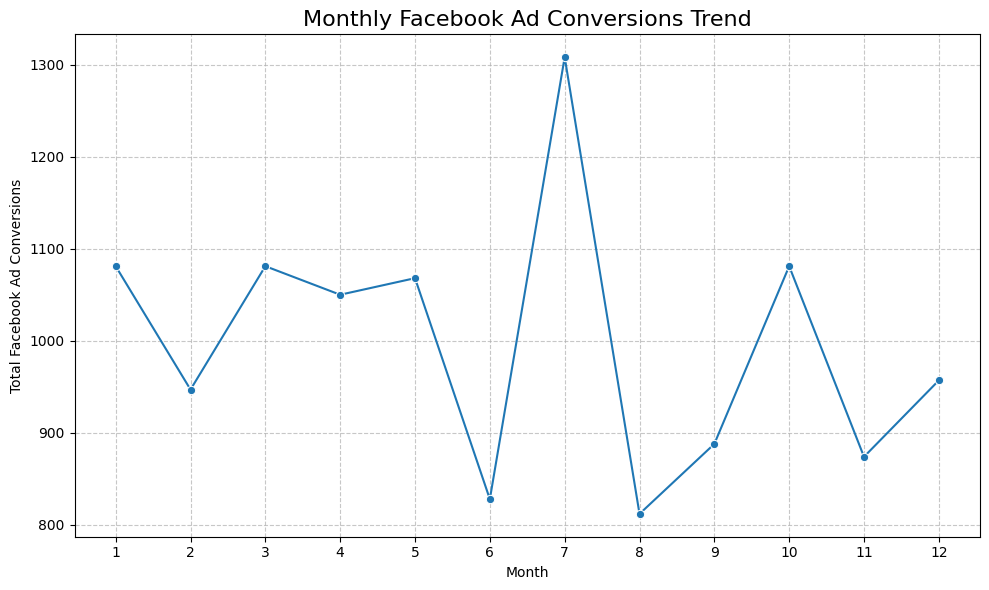

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure monthly_conversion is correctly computed (re-running for clarity, though it might exist)
monthly_conversion = df.groupby('month')[['facebook_ad_conversions']].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='month', y='facebook_ad_conversions', data=monthly_conversion, marker='o')
plt.title('Monthly Facebook Ad Conversions Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Facebook Ad Conversions')
plt.xticks(monthly_conversion['month'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.title('Monthly Facebook Ad Conversions')
monthly_conversion=df.groupby('month')[['facebook_ad_conversions']].sum()
plt.bar(monthly_conversion.index, monthly_conversion['facebook_ad_conversions'], edgecolor='k')
plt.xlabel('Month')
plt.ylabel('Total Facebook Ad Conversions')
plt.xticks(monthly_conversion.index)
plt.show()

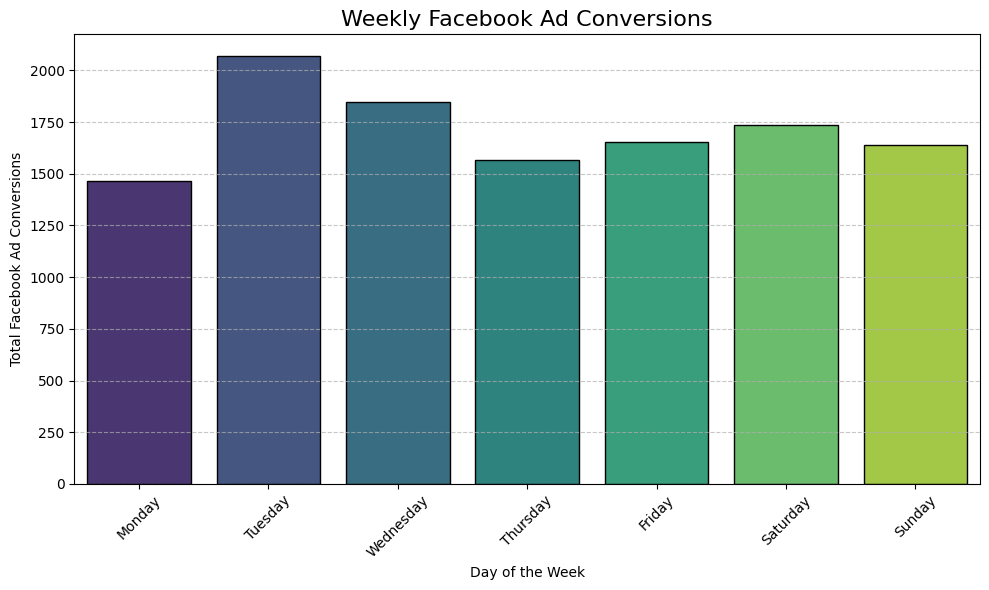

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure weekly_conversion is correctly computed (re-running for clarity)
weekly_conversion = df.groupby('week')[['facebook_ad_conversions']].sum().reset_index()
week_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_conversion['week_name'] = weekly_conversion['week'].map(lambda x: week_days[x])

plt.figure(figsize=(10, 6))
sns.barplot(x='week_name', y='facebook_ad_conversions', data=weekly_conversion, palette='viridis', edgecolor='k')
plt.title('Weekly Facebook Ad Conversions', fontsize=16)
plt.xlabel('Day of the Week')
plt.ylabel('Total Facebook Ad Conversions')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar plot illustrates the total Facebook ad conversions for each day of the week, allowing for easy comparison of conversion volumes across different days.

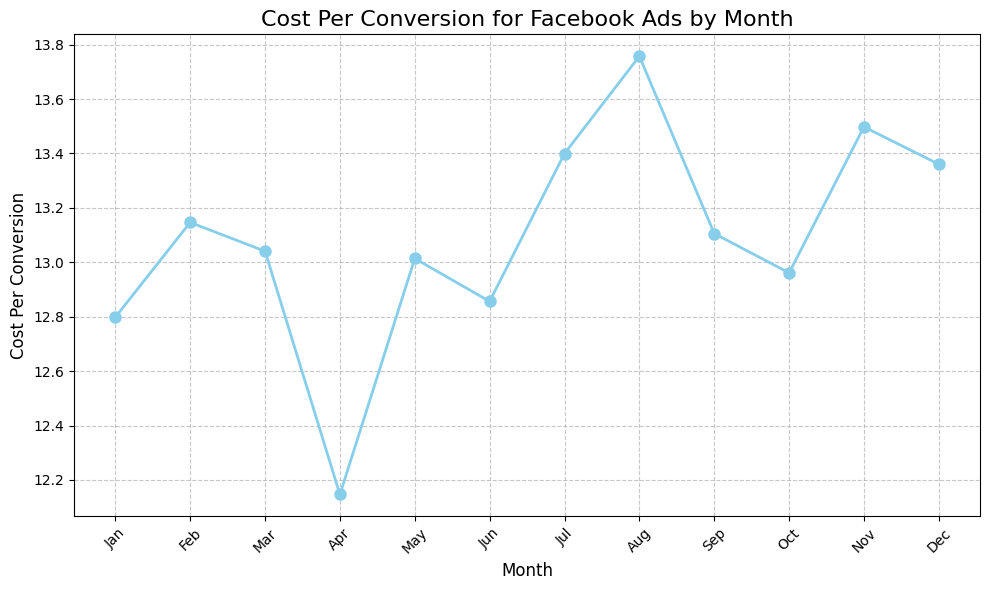

In [ ]:
import calendar

plt.figure(figsize=(10,6))
plt.title('Cost Per Conversion for Facebook Ads by Month', fontsize=16)
monthly_df=df.groupby('month')[['facebook_ad_conversions','facebook_cost_per_ad']].sum()
monthly_df['cost per conversion']=monthly_df['facebook_cost_per_ad']/monthly_df['facebook_ad_conversions']

# Get month names from month numbers
month_names = [calendar.month_abbr[month] for month in monthly_df.index]

plt.plot(month_names, monthly_df['cost per conversion'], '-o', color='skyblue', linewidth=2, markersize=8)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Cost Per Conversion', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
score, p_value, _=coint(df['facebook_cost_per_ad'], df['facebook_ad_conversions'])
print('cointegration test score:', score)
print('P-value:', p_value)

if p_value<0.05:
  print('Reject the null hypothesis')
else:
  print('Accept the null hypothesis')

cointegration test score: -31.718943132420478
P-value: 0.0
Reject the null hypothesis
